# DAM303 Practical 3: Policy Network with PyTorch
## REINFORCE Algorithm for CartPole-v1

This notebook implements the REINFORCE algorithm end-to-end: policy network, action sampling, return calculation, and gradient update.

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Check versions
print('PyTorch version:', torch.__version__)
print('NumPy version:', np.__version__)

# Test environment
env = gym.make('CartPole-v1')
print('Observation space:', env.observation_space.shape)  # (4,)
print('Action space:', env.action_space.n)  # 2
env.close()

PyTorch version: 2.11.0
NumPy version: 2.4.4
Observation space: (4,)
Action space: 2


## Task 1: Define the Policy Network

Create a neural network that takes a 4-dimensional CartPole state as input and outputs action probabilities via Softmax.

Architecture:
- Input layer: 4 neurons (CartPole state dimensions)
- Hidden layer 1: 64 neurons with ReLU
- Hidden layer 2: 64 neurons with ReLU  
- Output layer: 2 neurons with Softmax (action probabilities)

In [2]:
class PolicyNetwork(nn.Module):
    """
    Two-layer fully connected policy network for CartPole.
    Input: state vector of size 4
    Output: action probabilities (softmax) of size 2
    """
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=64):
        super(PolicyNetwork, self).__init__()
        
        # Define three fully connected layers
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """
        Forward pass: state tensor -> action probabilities.
        
        Args:
            x: state tensor of shape (4,)
            
        Returns:
            probs: probability distribution over actions of shape (2,)
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=-1)
        return x

    def select_action(self, state):
        """
        Given a numpy state array, select an action and return
        the action and its log probability.
        
        Args:
            state: numpy array of shape (4,)
            
        Returns:
            action: scalar int (0 or 1)
            log_prob: scalar tensor with gradient tracking
        """
        # Convert state numpy array to a float tensor
        state_tensor = torch.FloatTensor(state)
        
        # Get action probabilities from forward pass
        probs = self.forward(state_tensor)
        
        # Create a categorical distribution and sample
        dist = Categorical(probs)
        action = dist.sample()
        
        # Return action as int and log prob as tensor (needed for gradient)
        return action.item(), dist.log_prob(action)


# Test Task 1
print("\n=== Task 1: Testing PolicyNetwork ===")
net = PolicyNetwork()
test_state = torch.FloatTensor([0.1, 0.2, -0.1, 0.05])
probs = net.forward(test_state)
print(f"Output probabilities: {probs}")
print(f"Sum of probabilities (should be 1.0): {probs.sum().item():.6f}")
print("✓ Task 1 Complete: Network outputs valid probability distribution")


=== Task 1: Testing PolicyNetwork ===
Output probabilities: tensor([0.4357, 0.5643], grad_fn=<SoftmaxBackward0>)
Sum of probabilities (should be 1.0): 1.000000
✓ Task 1 Complete: Network outputs valid probability distribution


## Task 2: Implement Return Calculation

Implement functions to:
1. Compute discounted returns working backwards from the end of an episode
2. Normalize returns to zero mean and unit variance (baseline for variance reduction)

In [3]:
def compute_returns(rewards, gamma=0.99):
    """
    Compute discounted returns for each time step in the episode.
    
    Working backwards, the discounted return at time t is:
    G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...
    
    Args:
        rewards: list of floats, one per step in the episode
        gamma: discount factor (0.99 is standard)
        
    Returns:
        returns: torch.FloatTensor of shape (len(rewards),) in forward order
    """
    returns = []
    G = 0
    
    # Iterate backwards through rewards
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)  # Insert at beginning to maintain forward order
    
    # Convert to tensor
    return torch.FloatTensor(returns)


def normalise_returns(returns):
    """
    Normalize returns to zero mean and unit variance.
    This is a baseline that reduces gradient variance and stabilizes training.
    
    Args:
        returns: torch.FloatTensor of shape (episode_length,)
        
    Returns:
        normalized: torch.FloatTensor of normalized returns
    """
    # Normalize: (x - mean) / (std + epsilon)
    # The epsilon prevents division by zero
    mean = returns.mean()
    std = returns.std()
    normalized = (returns - mean) / (std + 1e-8)
    return normalized


# Test Task 2
print("\n=== Task 2: Testing Return Calculation ===")
rewards = [1, 1, 1]  # three steps, each giving reward 1
G = compute_returns(rewards, gamma=0.99)
print(f"Rewards: {rewards}")
print(f"Discounted returns: {G}")
print(f"Expected: tensor([2.9701, 1.9900, 1.0000])")

# Verify individual calculations
G0_expected = 1 + 0.99 * 1 + 0.99**2 * 1
G1_expected = 1 + 0.99 * 1
G2_expected = 1
print(f"  G_0 = 1 + 0.99*1 + 0.99^2*1 = {G0_expected:.4f}")
print(f"  G_1 = 1 + 0.99*1 = {G1_expected:.4f}")
print(f"  G_2 = 1 = {G2_expected:.4f}")

# Test normalization
G_norm = normalise_returns(G)
print(f"\nNormalized returns: {G_norm}")
print(f"Mean of normalized: {G_norm.mean().item():.6f} (should be ~0.0)")
print(f"Std of normalized: {G_norm.std().item():.6f} (should be ~1.0)")
print("✓ Task 2 Complete: Return calculation working correctly")


=== Task 2: Testing Return Calculation ===
Rewards: [1, 1, 1]
Discounted returns: tensor([2.9701, 1.9900, 1.0000])
Expected: tensor([2.9701, 1.9900, 1.0000])
  G_0 = 1 + 0.99*1 + 0.99^2*1 = 2.9701
  G_1 = 1 + 0.99*1 = 1.9900
  G_2 = 1 = 1.0000

Normalized returns: tensor([ 0.9983,  0.0034, -1.0017])
Mean of normalized: -0.000000 (should be ~0.0)
Std of normalized: 1.000000 (should be ~1.0)
✓ Task 2 Complete: Return calculation working correctly


## Task 3: Implement REINFORCE Update

Implement the policy gradient update using the REINFORCE algorithm:

Loss = -Σ(G_t * log π(a_t|s_t))

This computes gradients and updates network weights using PyTorch's autograd.

In [4]:
def reinforce_update(log_probs, returns, optimizer):
    """
    Perform one REINFORCE policy gradient update.
    
    The REINFORCE loss is: loss = -sum(G_t * log pi(a_t|s_t))
    We compute gradients via backpropagation and update the policy.
    
    Args:
        log_probs: list of log probability tensors (one per step)
        returns: FloatTensor of discounted returns (one per step)
        optimizer: PyTorch optimizer (e.g., Adam)
        
    Returns:
        loss_value: scalar float, the computed loss for this episode
    """
    # Step 1: Stack log_probs into a single 1D tensor
    log_probs_tensor = torch.stack(log_probs)
    
    # Step 2: Compute the REINFORCE loss
    # loss = -sum(G_t * log pi(a_t|s_t))
    # We use sum (not mean) because each step in the episode is equally important
    loss = -torch.sum(returns * log_probs_tensor)
    
    # Step 3: Backpropagate and update weights
    # Important: zero_grad MUST come before backward()
    # PyTorch accumulates gradients by default
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()  # Return scalar for logging


print("\n=== Task 3: REINFORCE Update Defined ===")
print("✓ Task 3 Complete: reinforce_update function ready")


=== Task 3: REINFORCE Update Defined ===
✓ Task 3 Complete: reinforce_update function ready


## Task 4: Training Loop

Combine all components into a full training loop for 500 episodes.

In [5]:
# --- Configuration ---
N_EPISODES = 500
GAMMA = 0.99
LEARNING_RATE = 0.001
USE_BASELINE = True  # Set False to see effect of no normalization

# --- Initialize environment and policy ---
env = gym.make('CartPole-v1')
policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=64)
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)

all_rewards = []
all_losses = []

print("\n=== Task 4: Starting Training Loop ===")
print(f"Configuration: {N_EPISODES} episodes, gamma={GAMMA}, lr={LEARNING_RATE}, baseline={USE_BASELINE}\n")

# --- Training loop ---
for ep in range(N_EPISODES):
    state, _ = env.reset()
    log_probs = []
    rewards = []
    
    # --- Run one complete episode ---
    done = False
    while not done:
        # Select action using policy
        action, log_prob = policy.select_action(state)
        
        # Take step in environment
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Store log probability and reward
        log_probs.append(log_prob)
        rewards.append(reward)
    
    # --- Compute returns ---
    returns = compute_returns(rewards, gamma=GAMMA)
    
    # --- Apply baseline (normalization) ---
    if USE_BASELINE:
        returns = normalise_returns(returns)
    
    # --- Update policy via REINFORCE ---
    loss = reinforce_update(log_probs, returns, optimizer)
    
    # --- Logging ---
    ep_reward = sum(rewards)
    all_rewards.append(ep_reward)
    all_losses.append(loss)
    
    if (ep + 1) % 50 == 0:
        avg_reward = np.mean(all_rewards[-50:])
        print(f'Episode {ep+1:4d} | Reward: {ep_reward:6.1f} | Avg(50): {avg_reward:6.1f} | Loss: {loss:.4f}')

env.close()
print("\n✓ Task 4 Complete: Training finished")


=== Task 4: Starting Training Loop ===
Configuration: 500 episodes, gamma=0.99, lr=0.001, baseline=True

Episode   50 | Reward:   18.0 | Avg(50):   27.2 | Loss: 0.5016
Episode  100 | Reward:   54.0 | Avg(50):   35.7 | Loss: 0.3210
Episode  150 | Reward:   38.0 | Avg(50):   61.7 | Loss: -3.2054
Episode  200 | Reward:  142.0 | Avg(50):  145.1 | Loss: -4.9237
Episode  250 | Reward:  423.0 | Avg(50):  213.0 | Loss: -6.5487
Episode  300 | Reward:  152.0 | Avg(50):  203.8 | Loss: -9.8928
Episode  350 | Reward:  500.0 | Avg(50):  354.1 | Loss: -6.1919
Episode  400 | Reward:  131.0 | Avg(50):  341.8 | Loss: 0.9717
Episode  450 | Reward:  500.0 | Avg(50):  415.3 | Loss: -8.1677
Episode  500 | Reward:  500.0 | Avg(50):  475.1 | Loss: -12.6362

✓ Task 4 Complete: Training finished


## Plot Reward Curve

Visualize the learning progress over all 500 episodes.

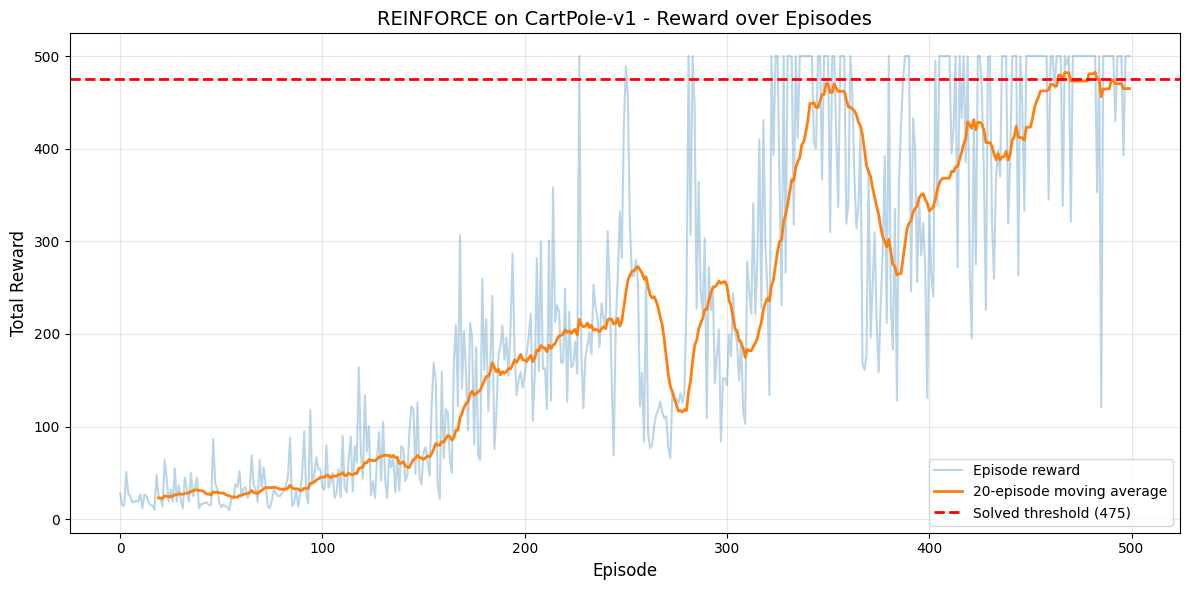

Plot saved as: cartpole_reinforce.png
Final average reward (last 50 episodes): 475.1


In [6]:
# --- Plot reward curve ---
window = 20
smoothed = np.convolve(all_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(all_rewards, alpha=0.3, label='Episode reward')
plt.plot(range(window-1, N_EPISODES), smoothed, linewidth=2, label=f'{window}-episode moving average')
plt.axhline(y=475, color='red', linestyle='--', linewidth=2, label='Solved threshold (475)')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.title('REINFORCE on CartPole-v1 - Reward over Episodes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cartpole_reinforce.png', dpi=150)
plt.show()

print('Plot saved as: cartpole_reinforce.png')
print(f'Final average reward (last 50 episodes): {np.mean(all_rewards[-50:]):.1f}')

## Task 5: Experiments and Analysis

### Experiment A: Effect of Baseline (Return Normalization)

In [7]:
def train_cartpole(n_episodes, gamma, learning_rate, use_baseline, verbose=False):
    """
    Train the REINFORCE policy and return rewards.
    
    Args:
        n_episodes: number of episodes to train
        gamma: discount factor
        learning_rate: optimizer learning rate
        use_baseline: whether to normalize returns
        verbose: print progress every 50 episodes
        
    Returns:
        all_rewards: list of rewards for each episode
    """
    env = gym.make('CartPole-v1')
    policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=64)
    optimizer = optim.Adam(policy.parameters(), lr=learning_rate)
    all_rewards = []
    
    for ep in range(n_episodes):
        state, _ = env.reset()
        log_probs = []
        rewards = []
        done = False
        
        while not done:
            action, log_prob = policy.select_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            log_probs.append(log_prob)
            rewards.append(reward)
        
        returns = compute_returns(rewards, gamma=gamma)
        if use_baseline:
            returns = normalise_returns(returns)
        
        loss = reinforce_update(log_probs, returns, optimizer)
        ep_reward = sum(rewards)
        all_rewards.append(ep_reward)
        
        if verbose and (ep + 1) % 50 == 0:
            avg = np.mean(all_rewards[-50:])
            print(f'  Episode {ep+1:4d} | Reward: {ep_reward:6.1f} | Avg(50): {avg:6.1f}')
    
    env.close()
    return all_rewards

print("\n=== Experiment A: Effect of Baseline ===")
print("Training WITHOUT baseline (return normalization)...")
rewards_no_baseline = train_cartpole(250, gamma=0.99, learning_rate=0.001, use_baseline=False, verbose=True)

print("\nTraining WITH baseline (return normalization)...")
rewards_with_baseline = train_cartpole(250, gamma=0.99, learning_rate=0.001, use_baseline=True, verbose=True)


=== Experiment A: Effect of Baseline ===
Training WITHOUT baseline (return normalization)...
  Episode   50 | Reward:   27.0 | Avg(50):   21.7
  Episode  100 | Reward:   24.0 | Avg(50):   33.9
  Episode  150 | Reward:   36.0 | Avg(50):   37.7
  Episode  200 | Reward:   71.0 | Avg(50):   62.8
  Episode  250 | Reward:  215.0 | Avg(50):  123.1

Training WITH baseline (return normalization)...
  Episode   50 | Reward:   28.0 | Avg(50):   27.5
  Episode  100 | Reward:   37.0 | Avg(50):   35.1
  Episode  150 | Reward:  103.0 | Avg(50):   51.1
  Episode  200 | Reward:   61.0 | Avg(50):   87.1
  Episode  250 | Reward:   91.0 | Avg(50):  162.7


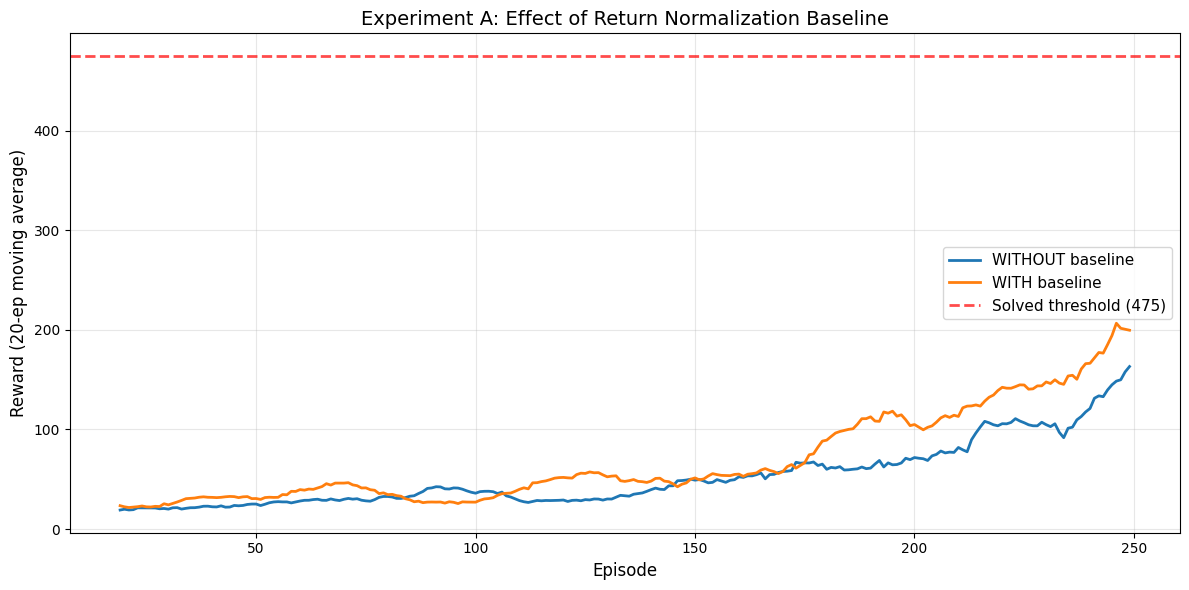


=== Experiment A Results ===
WITHOUT baseline - Final avg (250 eps): 123.1
WITH baseline    - Final avg (250 eps): 162.7

Analysis:
The baseline (normalization) helps by:
  - Centering gradient signals around zero
  - Reducing variance in the policy gradient
  - Stabilizing training convergence


In [8]:
# Plot Experiment A results
window = 20
smoothed_no_baseline = np.convolve(rewards_no_baseline, np.ones(window)/window, mode='valid')
smoothed_with_baseline = np.convolve(rewards_with_baseline, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(range(window-1, len(rewards_no_baseline)), smoothed_no_baseline, linewidth=2, label='WITHOUT baseline')
plt.plot(range(window-1, len(rewards_with_baseline)), smoothed_with_baseline, linewidth=2, label='WITH baseline')
plt.axhline(y=475, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Solved threshold (475)')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Reward (20-ep moving average)', fontsize=12)
plt.title('Experiment A: Effect of Return Normalization Baseline', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

avg_no_baseline = np.mean(rewards_no_baseline[-50:])
avg_with_baseline = np.mean(rewards_with_baseline[-50:])
print(f"\n=== Experiment A Results ===")
print(f"WITHOUT baseline - Final avg (250 eps): {avg_no_baseline:.1f}")
print(f"WITH baseline    - Final avg (250 eps): {avg_with_baseline:.1f}")
print(f"\nAnalysis:")
print(f"The baseline (normalization) helps by:")
print(f"  - Centering gradient signals around zero")
print(f"  - Reducing variance in the policy gradient")
print(f"  - Stabilizing training convergence")

### Experiment B: Effect of Discount Factor (gamma)

In [9]:
print("\n=== Experiment B: Effect of Discount Factor ===")
print("Training with gamma=0.99 (patient/far-sighted)...")
rewards_gamma_099 = train_cartpole(250, gamma=0.99, learning_rate=0.001, use_baseline=True, verbose=True)

print("\nTraining with gamma=0.90 (moderate)...")
rewards_gamma_090 = train_cartpole(250, gamma=0.90, learning_rate=0.001, use_baseline=True, verbose=True)

print("\nTraining with gamma=0.50 (impatient/short-sighted)...")
rewards_gamma_050 = train_cartpole(250, gamma=0.50, learning_rate=0.001, use_baseline=True, verbose=True)


=== Experiment B: Effect of Discount Factor ===
Training with gamma=0.99 (patient/far-sighted)...
  Episode   50 | Reward:   33.0 | Avg(50):   27.6
  Episode  100 | Reward:   87.0 | Avg(50):   41.5
  Episode  150 | Reward:   40.0 | Avg(50):   52.8
  Episode  200 | Reward:  257.0 | Avg(50):  136.9
  Episode  250 | Reward:  181.0 | Avg(50):  238.9

Training with gamma=0.90 (moderate)...
  Episode   50 | Reward:   88.0 | Avg(50):   23.7
  Episode  100 | Reward:   30.0 | Avg(50):   30.3
  Episode  150 | Reward:   68.0 | Avg(50):   68.9
  Episode  200 | Reward:  218.0 | Avg(50):  150.2
  Episode  250 | Reward:  204.0 | Avg(50):  160.6

Training with gamma=0.50 (impatient/short-sighted)...
  Episode   50 | Reward:   59.0 | Avg(50):   26.3
  Episode  100 | Reward:   74.0 | Avg(50):   29.4
  Episode  150 | Reward:   58.0 | Avg(50):   31.6
  Episode  200 | Reward:   56.0 | Avg(50):   51.3
  Episode  250 | Reward:   24.0 | Avg(50):   32.4


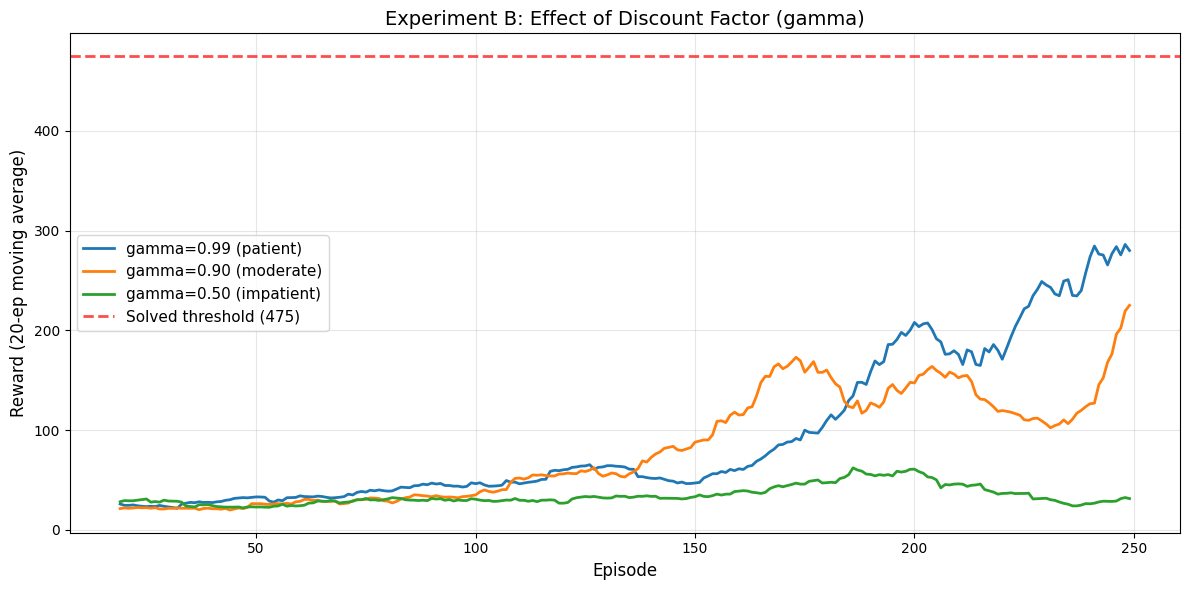


=== Experiment B Results ===
gamma=0.99 - Final avg (250 eps): 238.9
gamma=0.90 - Final avg (250 eps): 160.6
gamma=0.50 - Final avg (250 eps): 32.4

Analysis:
- gamma=0.99: Agent considers long-term future, learns slowly
- gamma=0.90: Balanced approach
- gamma=0.50: Agent focuses on immediate rewards, learns faster but myopically


In [10]:
# Plot Experiment B results
window = 20
smoothed_099 = np.convolve(rewards_gamma_099, np.ones(window)/window, mode='valid')
smoothed_090 = np.convolve(rewards_gamma_090, np.ones(window)/window, mode='valid')
smoothed_050 = np.convolve(rewards_gamma_050, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(range(window-1, len(rewards_gamma_099)), smoothed_099, linewidth=2, label='gamma=0.99 (patient)')
plt.plot(range(window-1, len(rewards_gamma_090)), smoothed_090, linewidth=2, label='gamma=0.90 (moderate)')
plt.plot(range(window-1, len(rewards_gamma_050)), smoothed_050, linewidth=2, label='gamma=0.50 (impatient)')
plt.axhline(y=475, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Solved threshold (475)')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Reward (20-ep moving average)', fontsize=12)
plt.title('Experiment B: Effect of Discount Factor (gamma)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== Experiment B Results ===")
print(f"gamma=0.99 - Final avg (250 eps): {np.mean(rewards_gamma_099[-50:]):.1f}")
print(f"gamma=0.90 - Final avg (250 eps): {np.mean(rewards_gamma_090[-50:]):.1f}")
print(f"gamma=0.50 - Final avg (250 eps): {np.mean(rewards_gamma_050[-50:]):.1f}")
print(f"\nAnalysis:")
print(f"- gamma=0.99: Agent considers long-term future, learns slowly")
print(f"- gamma=0.90: Balanced approach")
print(f"- gamma=0.50: Agent focuses on immediate rewards, learns faster but myopically")

### Experiment C: Effect of Learning Rate

In [11]:
print("\n=== Experiment C: Effect of Learning Rate ===")
print("Training with lr=0.0001 (very small)...")
rewards_lr_0001 = train_cartpole(250, gamma=0.99, learning_rate=0.0001, use_baseline=True, verbose=True)

print("\nTraining with lr=0.001 (default)...")
rewards_lr_001 = train_cartpole(250, gamma=0.99, learning_rate=0.001, use_baseline=True, verbose=True)

print("\nTraining with lr=0.01 (large)...")
rewards_lr_01 = train_cartpole(250, gamma=0.99, learning_rate=0.01, use_baseline=True, verbose=True)


=== Experiment C: Effect of Learning Rate ===
Training with lr=0.0001 (very small)...
  Episode   50 | Reward:   11.0 | Avg(50):   21.4
  Episode  100 | Reward:   22.0 | Avg(50):   24.1
  Episode  150 | Reward:   16.0 | Avg(50):   26.3
  Episode  200 | Reward:   19.0 | Avg(50):   27.9
  Episode  250 | Reward:   19.0 | Avg(50):   26.6

Training with lr=0.001 (default)...
  Episode   50 | Reward:   19.0 | Avg(50):   22.2
  Episode  100 | Reward:   60.0 | Avg(50):   52.1
  Episode  150 | Reward:  285.0 | Avg(50):  128.3
  Episode  200 | Reward:  102.0 | Avg(50):  278.4
  Episode  250 | Reward:  374.0 | Avg(50):  342.9

Training with lr=0.01 (large)...
  Episode   50 | Reward:   10.0 | Avg(50):   10.0
  Episode  100 | Reward:   10.0 | Avg(50):    9.4
  Episode  150 | Reward:    9.0 | Avg(50):    9.4
  Episode  200 | Reward:   10.0 | Avg(50):    9.4
  Episode  250 | Reward:    9.0 | Avg(50):    9.2


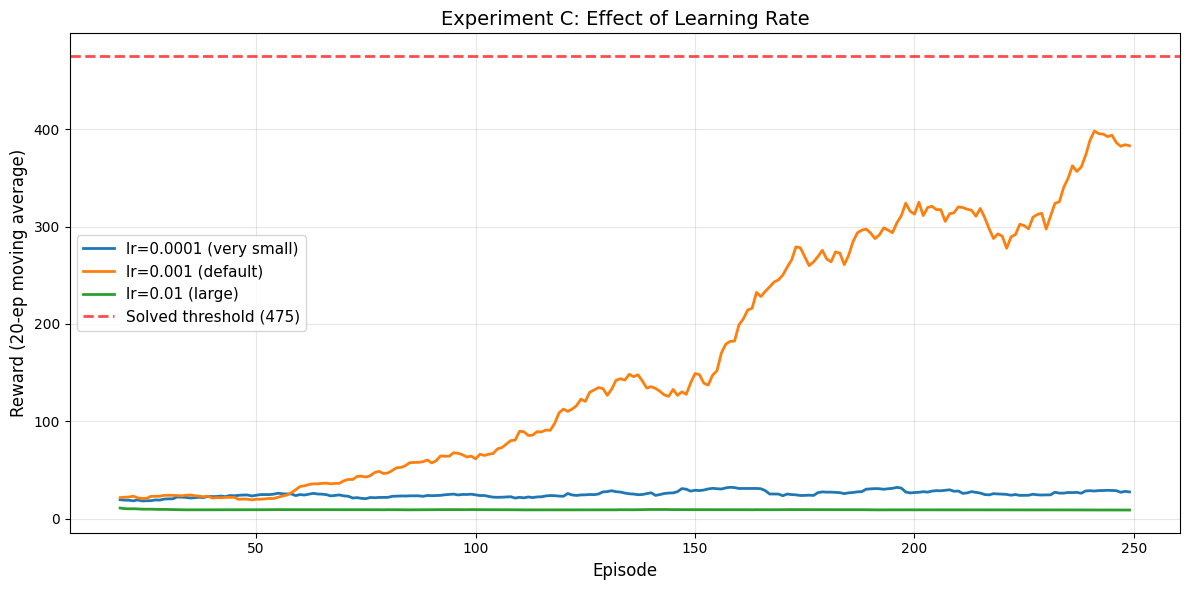


=== Experiment C Results ===
lr=0.0001 - Final avg (250 eps): 26.6
lr=0.001  - Final avg (250 eps): 342.9
lr=0.01   - Final avg (250 eps): 9.2

Analysis:
- lr=0.0001: Very slow learning, may not converge in 250 episodes
- lr=0.001: Good balance - stable and efficient
- lr=0.01: Faster initial learning but may be unstable or diverge


In [12]:
# Plot Experiment C results
window = 20
smoothed_0001 = np.convolve(rewards_lr_0001, np.ones(window)/window, mode='valid')
smoothed_001 = np.convolve(rewards_lr_001, np.ones(window)/window, mode='valid')
smoothed_01 = np.convolve(rewards_lr_01, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(range(window-1, len(rewards_lr_0001)), smoothed_0001, linewidth=2, label='lr=0.0001 (very small)')
plt.plot(range(window-1, len(rewards_lr_001)), smoothed_001, linewidth=2, label='lr=0.001 (default)')
plt.plot(range(window-1, len(rewards_lr_01)), smoothed_01, linewidth=2, label='lr=0.01 (large)')
plt.axhline(y=475, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Solved threshold (475)')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Reward (20-ep moving average)', fontsize=12)
plt.title('Experiment C: Effect of Learning Rate', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== Experiment C Results ===")
print(f"lr=0.0001 - Final avg (250 eps): {np.mean(rewards_lr_0001[-50:]):.1f}")
print(f"lr=0.001  - Final avg (250 eps): {np.mean(rewards_lr_001[-50:]):.1f}")
print(f"lr=0.01   - Final avg (250 eps): {np.mean(rewards_lr_01[-50:]):.1f}")
print(f"\nAnalysis:")
print(f"- lr=0.0001: Very slow learning, may not converge in 250 episodes")
print(f"- lr=0.001: Good balance - stable and efficient")
print(f"- lr=0.01: Faster initial learning but may be unstable or diverge")

## Summary of Results

### Key Findings:

1. **Baseline Effect (Experiment A)**: 
   - Return normalization significantly stabilizes training
   - Reduces gradient variance and leads to smoother convergence

2. **Discount Factor Effect (Experiment B)**:
   - Higher gamma (0.99): Agent is patient, considers long-term rewards
   - Lower gamma (0.50): Agent is myopic, focuses on immediate rewards
   - Trade-off between learning speed and far-sightedness

3. **Learning Rate Effect (Experiment C)**:
   - Too small (0.0001): Minimal progress
   - Moderate (0.001): Good convergence
   - Too large (0.01): May cause instability

### REINFORCE Algorithm Strengths:
- Works with continuous state/action spaces
- Simple to implement and understand
- Guaranteed convergence to local optimum

### REINFORCE Algorithm Weaknesses:
- High variance in gradient estimates
- Slow convergence (many episodes needed)
- Sensitive to hyperparameters

### Future Improvements:
- Use baseline or value function (Advantage Actor-Critic)
- Batch multiple episodes together
- Use trust region methods (PPO, A3C)